<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/PDS_T3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas 3: Data Wrangling and Data Cleaning - Pengantar Data Sains**
**Analisis Statistik Dataset Gaming and Mental Health**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 4**

1.  **Cari dataset publik** (Kaggle / UCI / Google Dataset Search / data.go.id).
**Syarat:**
* ≥5 kolom
* Ada variabel numerik & kategorik
* Mengandung missing value atau potensi outlier

2. **Load data** ke DataFrame `df`

3. **Identifikasi Struktur Data**

* Observation (satu baris mewakili apa?)
* Variabel numerik
* Variabel kategorik

4. **Periksa Missing values**
* Hitung jumlah missing per kolom
* Pilih salah satu: hapus atau imputasi
* Jelaskan alasan keputusan

5. **Deteksi Outlier**

* Pilih satu variabel numerik utama
* Gunakan boxplot atau metode lain
* Tentukan apakah ada outlier
* Jelaskan apakah outlier dihapus atau dipertahankan


6. **Transformasi Data**
*  Lakukan minimal satu transformasi pada variabel numerik
* Bandingkan distribusi sebelum dan sesudah transformasi.

7. **Penjelasan singkat**

---

### **Output**

1. Tabel ringkasan missing
2. Bukti deteksi outlier
3. Grafik sebelum/sesudah transformasi
4. Interpretasi singkat

## 1) Dataset Publik dari Kaggle

### Deskripsi dataset
Dataset yang digunakan adalah **Gaming and Mental Health** yang diperoleh dari [Kaggle](https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health). Dataset ini berisi informasi mengenai perilaku bermain game serta dampaknya terhadap pola tidur dan gaya hidup.

Setiap baris merepresentasikan 1 individu (gamer) dengan karakteristik demografis, durasi bermain game, genre dan platform game yang digunakan, kualitas tidur, serta indikator risiko kecanduan.

### Jumlah observasi
Dataset terdiri dari **1.000 baris (observasi) dengan 27 kolom (variabel)**.

### Cakupan variabel
- Identitas & Demografi: `record_id`, `age`, `gender`
- Perilaku Gaming: `daily_gaming_hours`, `game_genre`, `primary_game`, `gaming_platform`, `years_gaming`, `monthly_game_spending_usd`
- Tidur & Kesehatan: `sleep_hours`, `sleep_quality`, `sleep_disruption_frequency`, `eye_strain`, `back_neck_pain`
- Akademik & Produktivitas: `academic_work_performance`, `grades_gpa`, `work_productivity_score`
- Kondisi Psikologis & Emosional: `mood_state`, `mood_swing_frequency`, `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`
- Gaya Hidup & Sosial: `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`
- Risiko Kecanduan: `gaming_addiction_risk_level`

Sumber dataset:
[Gaming and Mental Health – Kaggle](https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health)

## 2) Load Data ke DataFrame df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Gaming and Mental Health.csv")
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


## 3) Identifikasi Struktur Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("\nVariabel numerik:")
print(num_cols)

cat_cols = df.select_dtypes(include=['object','bool']).columns
print("\nVariabel kategorik:")
print(cat_cols)


Variabel numerik:
Index(['age', 'daily_gaming_hours', 'sleep_hours', 'grades_gpa',
       'work_productivity_score', 'weight_change_kg', 'exercise_hours_weekly',
       'social_isolation_score', 'face_to_face_social_hours_weekly',
       'monthly_game_spending_usd', 'years_gaming'],
      dtype='object')

Variabel kategorik:
Index(['record_id', 'gender', 'game_genre', 'primary_game', 'gaming_platform',
       'sleep_quality', 'sleep_disruption_frequency',
       'academic_work_performance', 'mood_state', 'mood_swing_frequency',
       'withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain',
       'gaming_addiction_risk_level'],
      dtype='object')


**Interpretasi:**

### a) Observation

Berdasarkan struktur dataset, setiap baris merepresentasikan **1 individu (gamer)** dengan berbagai karakteristik yang mencakup aspek demografi, perilaku gaming, kesehatan, produktivitas, kondisi psikologis, serta indikator risiko kecanduan.

Dataset terdiri dari **1.000 observasi dan 27 variabel**, sehingga ukuran data tergolong cukup untuk analisis eksploratif (Exploratory Data Analysis / EDA) dan memungkinkan identifikasi pola perilaku gaming secara umum.

### b) Variabel numerik

Variabel numerik terdiri dari:

`age`, `daily_gaming_hours`, `sleep_hours`, `grades_gpa`, `work_productivity_score`, `weight_change_kg`, `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`, `monthly_game_spending_usd`, dan `years_gaming`.

Variabel-variabel ini berbentuk data kuantitatif yang dapat digunakan untuk analisis statistik seperti perhitungan rata-rata, distribusi data, deteksi outlier, serta transformasi data.

### c) Variabel kategorik

Variabel kategorik terdiri dari:

`record_id`, `gender`, `game_genre`, `primary_game`, `gaming_platform`, `sleep_quality`, `sleep_disruption_frequency`, `academic_work_performance`, `mood_state`, `mood_swing_frequency`, `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`, `eye_strain`, `back_neck_pain`, dan `gaming_addiction_risk_level`.

Variabel ini digunakan untuk analisis berbasis kategori seperti grouping, pivot table, atau perbandingan antar kelompok. Beberapa variabel boolean seperti `withdrawal_symptoms` dan `eye_strain` juga dapat diperlakukan sebagai variabel kategorik biner karena hanya memiliki dua kemungkinan nilai (True/False).


## 4) Missing Value

Missing value adalah proses **mengidentifikasi, menganalisis, dan menangani data yang hilang** dalam dataset agar tidak mengganggu hasil analisis atau model. Data yang hilang dapat terjadi karena berbagai alasan seperti kesalahan pengumpulan data, responden tidak menjawab, kesalahan sistem, atau data tidak tercatat.

Pengisian missing value dapat menggunakan mean atau median.

- Mean digunakan jika distribusi data normal dan tidak memiliki outlier ekstrem.
- Median digunakan jika data cenderung skewed atau memiliki outlier karena median lebih robust (tidak terpengaruh nilai ekstrem).

In [ ]:
# Missing Value sebelum imputasi
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [ ]:
# Missing Value setelah imputasi median
imputer = df.median(numeric_only=True)
df_imputed = df.fillna(imputer)

df_imputed.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


**Interpretasi:**

Hasil pemeriksaan missing value sebelum proses imputasi menunjukkan bahwa sebagian besar variabel dalam dataset tidak memiliki data yang hilang. Namun, terdapat dua variabel yang memiliki missing value yaitu `grades_gpa` sebanyak **246 data (24,6%)** dan `work_productivity_score` sebanyak **326 data (32,6%)**. Persentase missing value pada kedua variabel tersebut cukup besar (≥ 5%) sehingga missing value tidak langsung dihapus karena dapat mengurangi jumlah observasi secara signifikan serta berpotensi menimbulkan bias pada analisis.

Untuk mengatasi permasalahan tersebut, dilakukan proses imputasi dengan mengganti nilai yang hilang menggunakan **median**. Pemilihan median didasarkan pada karakteristik data numerik seperti GPA dan skor produktivitas yang berpotensi memiliki distribusi tidak simetris (*skewed*) serta kemungkinan adanya nilai ekstrem (*outlier*). Median dipilih karena lebih robust terhadap outlier dan mampu merepresentasikan nilai tengah data secara lebih stabil dibandingkan mean.

Setelah proses imputasi dilakukan, hasil pemeriksaan kembali menunjukkan bahwa seluruh variabel dalam dataset sudah memiliki nilai **0 missing value**. Dengan demikian, dataset telah bersih dari missing value dan siap digunakan untuk tahap analisis data selanjutnya.



## 5) Deteksi Outlier



In [ ]:
Q1 = df_imputed['daily_gaming_hours'].quantile(0.25)
Q3 = df_imputed['daily_gaming_hours'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print("Q1 :",Q1)
print("Q3 :",Q3)
print("IQR :",IQR)
print("Lower bound :",lower_bound)
print("Upper bound :",upper_bound)

outliers = df_imputed[
    (df_imputed['daily_gaming_hours'] < lower_bound) |
    (df_imputed['daily_gaming_hours'] > upper_bound)
]

print("Jumlah outlier:",outliers.shape[0])

Q1 : 4.1
Q3 : 8.025
IQR : 3.9250000000000007
Lower bound : -1.7875000000000014
Upper bound : 13.912500000000001
Jumlah outlier: 6


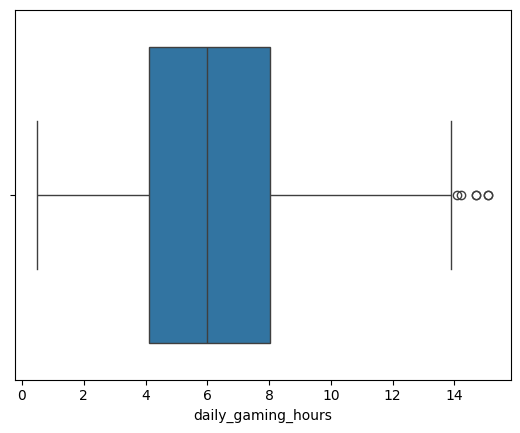

In [ ]:
# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_imputed['daily_gaming_hours'])
plt.show()

**Interpretasi:**

Deteksi outlier pada variabel `daily_gaming_hours` dilakukan menggunakan metode **Interquartile Range (IQR)**. Berdasarkan perhitungan, diperoleh **Q1 = 4.1** dan **Q3 = 8.025**, serta nilai **IQR = 3.925**. Dari nilai tersebut, diperoleh **lower bound = -1.7875** dan **upper bound = 13.9125** sebagai batas untuk mengidentifikasi nilai outlier.

Hasil analisis menunjukkan terdapat **6 observasi** yang berada di luar rentang tersebut sehingga dikategorikan sebagai outlier. Jumlah ini relatif kecil dibandingkan keseluruhan data.

Visualisasi **boxplot** juga menunjukkan beberapa titik di luar whisker yang mengkonfirmasi keberadaan outlier pada variabel `daily_gaming_hours`. Outlier tersebut tidak dihapus karena masih dianggap realistis dan kemungkinan merepresentasikan kelompok **heavy gamers** dengan durasi bermain yang jauh lebih tinggi dibandingkan mayoritas responden. Oleh karena itu, data tetap dipertahankan agar variasi perilaku gaming tetap tercermin dalam dataset.

## 6) Transformasi Data

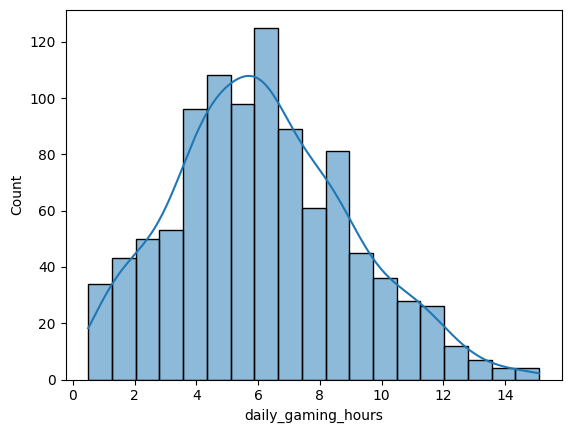

In [ ]:
# Sebelum
sns.histplot(df_imputed['daily_gaming_hours'],kde=True)
plt.show()

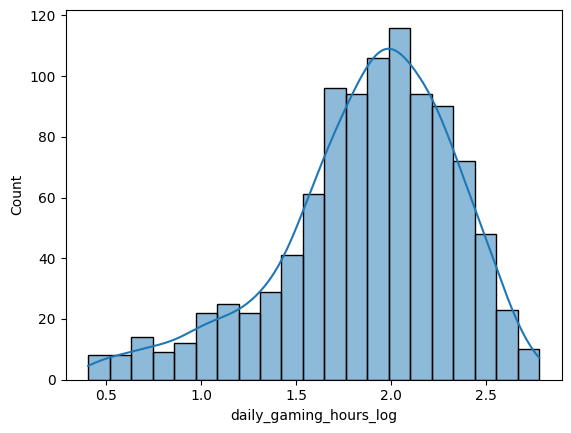

In [ ]:
# Transformasi log
df_imputed['daily_gaming_hours_log'] = np.log1p(df_imputed['daily_gaming_hours'])
# Sesudah
sns.histplot(df_imputed['daily_gaming_hours_log'],kde=True)
plt.show()

**Interpretasi:**

Transformasi dilakukan pada variabel `daily_gaming_hours` menggunakan **transformasi log** untuk memperbaiki bentuk distribusi data.

Sebelum transformasi, distribusi menunjukkan kecenderungan **right skewed**, di mana terdapat sebagian kecil individu dengan durasi bermain sangat tinggi yang menyebabkan distribusi tidak simetris.

Setelah dilakukan transformasi log, distribusi menjadi lebih mendekati simetris karena:
- Nilai ekstrem menjadi lebih terkompresi
- Variasi data menjadi lebih stabil
- Skewness berkurang

Transformasi ini bermanfaat terutama jika data akan digunakan dalam pemodelan statistik atau machine learning, karena banyak metode analisis bekerja lebih optimal pada data dengan distribusi yang lebih mendekati normal.

## 7) Penjelasan Singkat

Dataset yang digunakan adalah **Gaming and Mental Health** yang diperoleh dari Kaggle. Dataset ini terdiri dari **1.000 observasi dan 27 variabel**, di mana setiap baris merepresentasikan **1 individu (gamer)** dengan informasi terkait perilaku bermain game, kondisi kesehatan, produktivitas, serta aspek psikologis dan sosial. Struktur dataset terdiri dari dua tipe variabel utama, yaitu variabel numerik dan kategorik.

### Missing Value

Hasil pemeriksaan menunjukkan bahwa missing value hanya terdapat pada dua variabel:

* `grades_gpa` : **246 data (24,6%)**
* `work_productivity_score` : **326 data (32,6%)**

Karena persentasenya cukup besar, data tidak dihapus agar jumlah observasi tidak berkurang secara signifikan. Sebagai gantinya dilakukan **imputasi menggunakan median** karena metode ini lebih stabil terhadap kemungkinan data yang skewed dan tidak terlalu dipengaruhi oleh nilai ekstrem.

Setelah proses imputasi dilakukan, seluruh variabel sudah memiliki **0 missing value** sehingga dataset siap digunakan untuk analisis selanjutnya.

### Deteksi Outlier

Deteksi outlier dilakukan pada variabel **`daily_gaming_hours`** menggunakan metode **Interquartile Range (IQR)**. Hasil perhitungan menunjukkan:

* **Q1 = 4.1**
* **Q3 = 8.025**
* **IQR = 3.925**
* **Lower bound = -1.7875**
* **Upper bound = 13.9125**

Berdasarkan batas tersebut, ditemukan **6 observasi** yang tergolong outlier. Outlier ini tidak dihapus karena jumlahnya kecil dan masih dianggap realistis untuk merepresentasikan gamer dengan durasi bermain yang sangat tinggi.

### Transformasi Data

Transformasi dilakukan pada variabel **`daily_gaming_hours`** menggunakan **log transformation** untuk memperbaiki distribusi data.

Sebelum transformasi, distribusi menunjukkan **right skewed** akibat beberapa nilai yang sangat tinggi. Setelah transformasi log, distribusi menjadi lebih mendekati simetris karena nilai ekstrem menjadi lebih terkompresi dan variasi data lebih stabil.